In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Elevate Labs/Heart_Disease_Dataset.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
# Separate features and target
X = df.drop("target", axis=1)
y = df["target"]

# Check shape
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1025, 13)
y shape: (1025,)


### **Train-Test Split and Standardization**

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **Train a Decision Tree Classifier and Visualize**

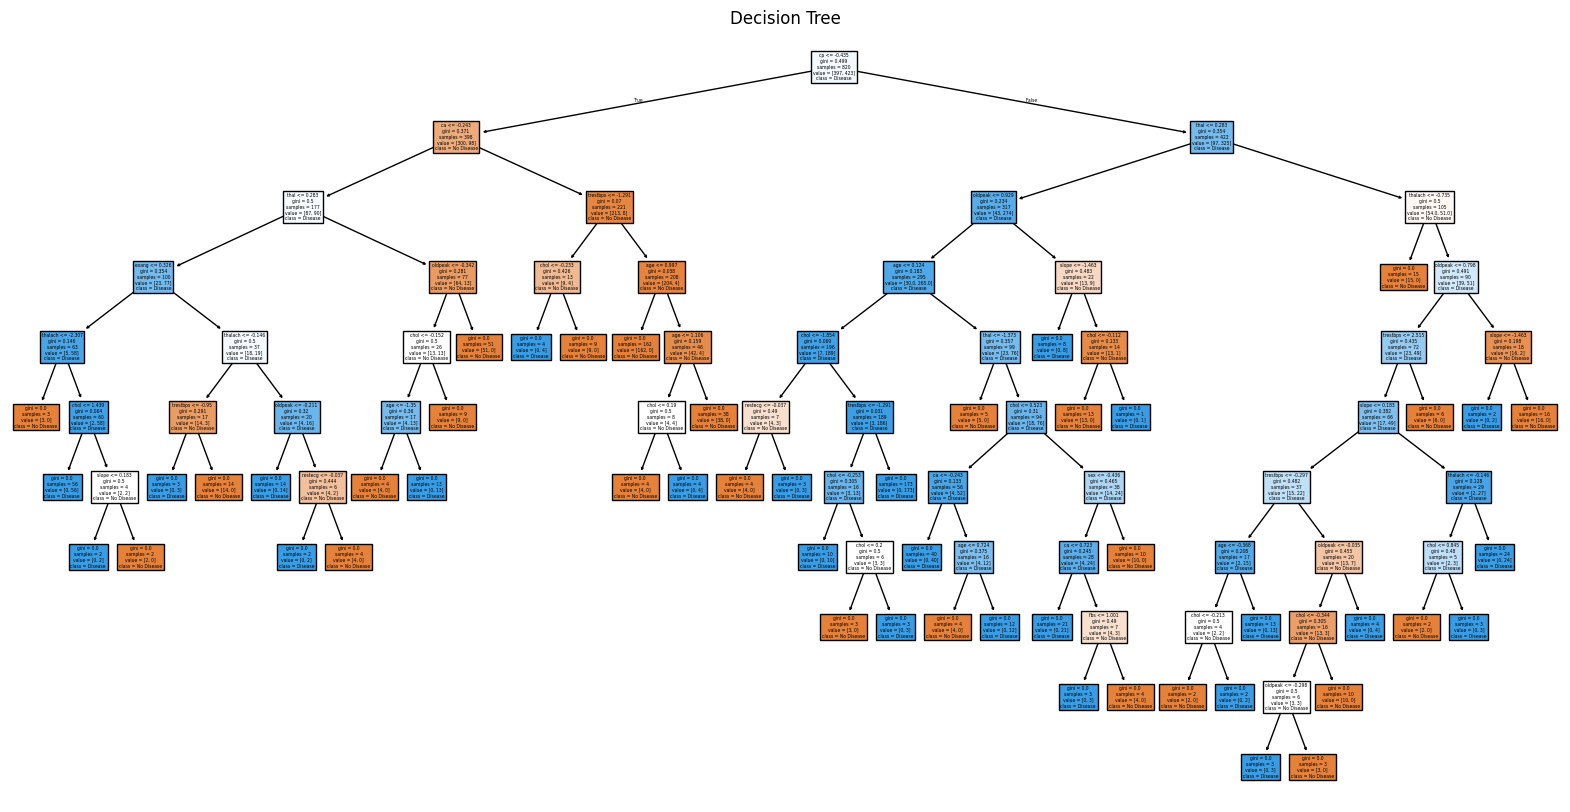

In [7]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import tree
import matplotlib.pyplot as plt

# Train decision tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)

# Visualize the tree
plt.figure(figsize=(20,10))
tree.plot_tree(dt, feature_names=X.columns, class_names=["No Disease", "Disease"], filled=True)
plt.title("Decision Tree")
plt.show()

### **Analyze Overfitting by Controlling Tree Depth**

In [8]:
# Limit tree depth
dt_limited = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_limited.fit(X_train_scaled, y_train)

# Accuracy scores
print("Full Tree Accuracy:", dt.score(X_test_scaled, y_test))
print("Limited Depth Accuracy:", dt_limited.score(X_test_scaled, y_test))

Full Tree Accuracy: 0.9853658536585366
Limited Depth Accuracy: 0.8


### **Train a Random Forest and Compare Accuracy**

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# Accuracy comparison
print("Random Forest Accuracy:", rf.score(X_test_scaled, y_test))
print("Decision Tree Accuracy:", dt_limited.score(X_test_scaled, y_test))

Random Forest Accuracy: 0.9853658536585366
Decision Tree Accuracy: 0.8


### **Feature Importance Interpretation**

In [10]:
import numpy as np

# Get feature importances from Random Forest
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Display top features
print("Feature importances:")
for i in indices:
    print(f"{X.columns[i]}: {importances[i]:.4f}")

Feature importances:
cp: 0.1351
ca: 0.1273
thalach: 0.1222
oldpeak: 0.1219
thal: 0.1105
age: 0.0779
chol: 0.0748
trestbps: 0.0712
exang: 0.0576
slope: 0.0458
sex: 0.0287
restecg: 0.0186
fbs: 0.0084


### **Evaluation using Cross-Validation**

In [11]:
from sklearn.model_selection import cross_val_score

# Cross-validation scores
rf_cv_scores = cross_val_score(rf, X, y, cv=5)
dt_cv_scores = cross_val_score(dt_limited, X, y, cv=5)

print("Random Forest CV Accuracy:", rf_cv_scores.mean())
print("Decision Tree (depth=4) CV Accuracy:", dt_cv_scores.mean())

Random Forest CV Accuracy: 0.9970731707317073
Decision Tree (depth=4) CV Accuracy: 0.8341463414634147
